In [48]:
import numpy as np
import pandas
import matplotlib.pyplot as plt
import sympy as sp
import scipy.stats

In [49]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/florisvb/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

#planar_drone = import_local_or_github('planar_drone', directory='../Utility')
plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')

# Load the data

And format it so the shapes and organization of the data matches standard mathematical notation.

### Load the arrays for the kalman filter

Colab tip: You may need to download them to your machine from notebook A, and then upload them to the colab environment where you are running this notebook.

In [50]:
# read from disk
loaded_arrays = np.load('ABCDRQ.npz')
A = loaded_arrays['A']
B = loaded_arrays['B']
C = loaded_arrays['C']
D = loaded_arrays['D']
R = loaded_arrays['R']
Q = loaded_arrays['Q']

In [51]:
Q = np.diag([1e-4]*7)
Q_big = np.diag([1]*7)
print('Q:')
sp.pretty_print( np.round(Q, 4))

Q:
[[0.0001 0.     0.     0.     0.     0.     0.    ] 
 [0.     0.0001 0.     0.     0.     0.     0.    ] 
 [0.     0.     0.0001 0.     0.     0.     0.    ] 
 [0.     0.     0.     0.0001 0.     0.     0.    ] 
 [0.     0.     0.     0.     0.0001 0.     0.    ] 
 [0.     0.     0.     0.     0.     0.0001 0.    ] 
 [0.     0.     0.     0.     0.     0.     0.0001]]


In [52]:
print('A shape: ', A.shape)
print('B shape: ', B.shape)
print('C shape: ', C.shape)
print('D shape: ', D.shape)
print('R shape: ', R.shape)
print('Q shape: ', Q.shape)

A shape:  (7, 7)
B shape:  (7, 2)
C shape:  (4, 7)
D shape:  (4, 2)
R shape:  (4, 4)
Q shape:  (7, 7)


### Load the state data and reorganize Y and U

Standard mathematical notation requires that each column of $Y$ correspond to the measurements at discrete time, i.e. $\mathbf{y}_k$, and each row of $\mathbf{y}$ correspond to each individual measurement. Similarly for $U$.

In [53]:
# read from disk
df_states = pandas.read_hdf('planar_drone_sim_states.hdf', 'states')
#
df_measurements_true = pandas.read_hdf('planar_drone_measurements.hdf')
df_measurements_noisy = pandas.read_hdf('planar_drone_measurements_noisy.hdf')

In [54]:
df_measurements_noisy = pandas.read_hdf('/content/planar_drone_measurements_noisy.hdf', 'planar_drone_measurements_noisy')

In [55]:
Y = np.vstack(df_measurements_noisy[['theta', 'x', 'z', 'k']].values).T
print(Y.shape)

(4, 200)


In [56]:
U = np.vstack(df_states[['j1', 'j2']].values).T
print(U.shape)

(2, 200)


### Tip: When you index Y or U, make sure you are keeping a column vector.

In [57]:
# This is wrong
y_0 = Y[:, 0]
print(y_0)

[0.02560144 2.09111516 0.77094953 1.00849955]


In [58]:
# This is right
y_0 = Y[:, [0]]
print(y_0)

[[0.02560144]
 [2.09111516]
 [0.77094953]
 [1.00849955]]


## Tip: matrix multiplication in python

Recall that matrix shape during multiplication works like:

$[N\times M][M\times 1]=[N\times 1]$

In [59]:
# Option 1 using arrays
print('R shape: ', R.shape)
print('y_0 shape: ', y_0.shape)
print('[R x y_0] shape', (R@y_0).shape)
print('')
print('[R x y_0] = ')
R@y_0

R shape:  (4, 4)
y_0 shape:  (4, 1)
[R x y_0] shape (4, 1)

[R x y_0] = 


array([[2.56014377e-04],
       [8.36446062e-02],
       [1.23351925e-01],
       [1.00849955e-04]])

In [60]:
# Option 2 using matrices -- NOTE: np.matrix is getting deprecated, sadly, so this is not recommended
R_times_y_0 = np.matrix(R)*np.matrix(y_0)
print('[R x y_0] = ')
R_times_y_0

[R x y_0] = 


matrix([[2.56014377e-04],
        [8.36446062e-02],
        [1.23351925e-01],
        [1.00849955e-04]])

# Exercises:

1. Code a linear discrete Kalman filter that uses the matrices and time series data defined above:
    * $A, B, C, D, R, Q$ matrices defined above
    * Measurements are given by $Y$
    * Controls are given by $U$
    * Choose an initial $\mathbf{x_0}$ and $P_0$
    * Try a larger value of Q, and a smaller value of Q. For this problem, does a larger or smaller value of Q lead to more accurate estimates? Why do you think that is?

2. Compare the error covariance of your Kalman filter to the Cramer Rao Bound. Is your KF efficient? Try for different values of Q.

3. Compare the error covariance of your KF and the CRB to the actual errors in your estimate. Does the distribution of the errors match that predicted by the error covariance and the CRB? Hint: the error covariance and the CRB report variance, the square of the standard deviation.

In [61]:
inv = np.linalg.inv

In [62]:
P0 = 10*np.eye(7)
x0 = np.array([[0, 0, 0, 0, 0, 0, 0]]).T

In [63]:
K_k = P0@(C.T)@(inv((C@P0@C.T + R))) # Kalman Gain


In [64]:
# Initialize state estimate and error covariance
x_hat = x0
P = P0

# Create lists to store the results
x_hat_history = [x_hat]
P_history = [P]

num_time_steps = Y.shape[1]

# Implement the Kalman filter loop
for k in range(num_time_steps):
    # Get the current measurement and control input
    y_k = Y[:, [k]]
    u_k = U[:, [k]]

    # Prediction step
    x_kplus1_neg = A @ x_hat + B @ u_k
    P_kplus1_neg = A @ P @ A.T + Q

    # Kalman Gain calculation
    K_kplus1 = P_kplus1_neg @ C.T @ inv(C @ P_kplus1_neg @ C.T + R)

    # Update step
    x_hat_kplus1_plus = x_kplus1_neg + K_kplus1 @ (y_k - C @ x_kplus1_neg - D @ u_k)
    P_kplus1_plus = (np.eye(P.shape[0]) - K_kplus1 @ C) @ P_kplus1_neg

    # Store results
    x_hat_history.append(x_hat_kplus1_plus)
    P_history.append(P_kplus1_plus)

    # Update for the next iteration
    x_hat = x_hat_kplus1_plus
    P = P_kplus1_plus

In [65]:
# Initialize state estimate and error covariance
x_hat = x0
P = P0

# Create lists to store the results
x_hat_history = [x_hat]
P_history = [P]

num_time_steps = Y.shape[1]

# Implement the Kalman filter loop
for k in range(num_time_steps):
    # Get the current measurement and control input
    y_k = Y[:, [k]]
    u_k = U[:, [k]]

    # Prediction step
    x_kplus1_neg = A @ x_hat + B @ u_k
    P_kplus1_neg = A @ P @ A.T + Q_big

    # Kalman Gain calculation
    K_kplus1 = P_kplus1_neg @ C.T @ inv(C @ P_kplus1_neg @ C.T + R)

    # Update step
    x_hat_kplus1_plus = x_kplus1_neg + K_kplus1 @ (y_k - C @ x_kplus1_neg - D @ u_k)
    P_kplus1_plus = (np.eye(P.shape[0]) - K_kplus1 @ C) @ P_kplus1_neg

    # Store results
    x_hat_history.append(x_hat_kplus1_plus)
    P_history.append(P_kplus1_plus)

    # Update for the next iteration
    x_hat = x_hat_kplus1_plus
    P = P_kplus1_plus

# Task
Compare the error covariance of your Kalman filter to the Cramer Rao Bound and determine if your KF is efficient for different values of Q.

In [66]:
def linear_discrete_kalman_forward_update(xhat_foward_plus, P_foward_plus, y, u,
                                          A,B,C,D,R,Q):
  ## Indentity matrix have the same size as A
  I = np.array(np.eye(A.shape[0]))

  ## predict
  xhat_foward_minus = A@xhat_foward_plus + B@u
  P_forward_minus = A@P_foward_plus@A.T +Q

  ## update
  K_foward = P_forward_minus@C.T@inv(C@P_forward_minus@C.T + R)

  yhat = C@xhat_foward_minus + D@u
  innovation = y - yhat
  xhat_foward_plus = xhat_foward_minus + K_foward@innovation
  P_forward_plus = (I-K_foward@C)@P_forward_minus

  return xhat_foward_plus, P_foward_plus

In [67]:
def linear_discrete_kalman_filter(x0, P0, Y, U, A, B, C, D, R, Q):
  x_hat_forward_plus = x0
  P_forward_plus = [P0]
  for i in range(Y.shape[1]):
    x_hat_forward_plus_i, P_forward_plus_i = linear_discrete_kalman_forward_update(x_hat_forward_plus[:, [-1]], P_forward_plus[-1], Y[:, [i]],
                                                                                   U[:, [i]],
                                                                                   A, B, C, D, R, Q)
    x_hat_forward_plus = np.hstack([x_hat_forward_plus, x_hat_forward_plus_i])
    P_forward_plus.append(P_forward_plus_i)



  return x_hat_forward_plus[:,1:], P_forward_plus[1:] # we want to exclude the first one becasue it does not have the filter or predcitive step so it means it is a bad mesurement.



In [68]:
x0 = np.atleast_2d([1]*A.shape[0]).T
x0

array([[1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1]])

In [69]:
P0 = np.eye(A.shape[0])*100

In [70]:
x_hat_forward_plus, P_forward_plus = linear_discrete_kalman_filter(x0, P0, Y, U, A, B, C, D, R, Q)

In [71]:
x_hat_forward_plus.shape

(7, 200)

<Axes: xlabel='Time', ylabel='x'>

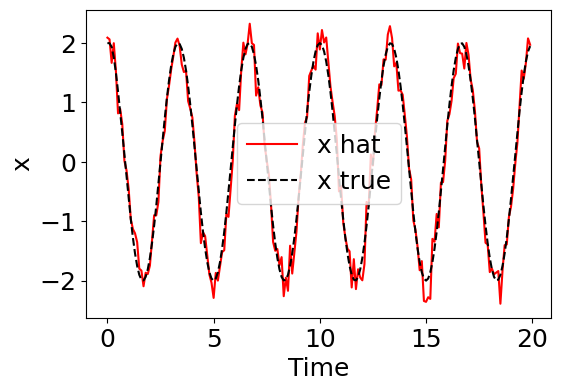

In [72]:
plot_tme(df_states.t, df_states['x'], None, x_hat_forward_plus[2,:], label_var='x')

In [86]:
Q = 1e-1*np.eye(A.shape[0])


<Axes: xlabel='Time', ylabel='x'>

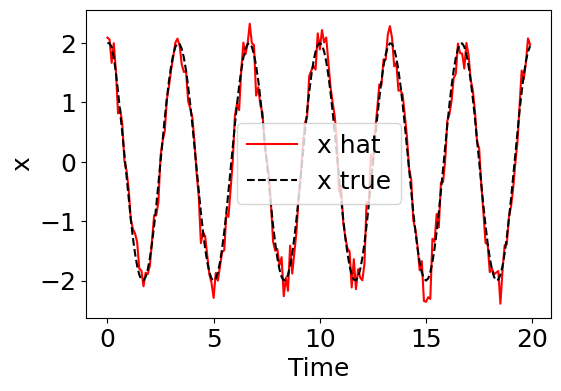

In [87]:
x_hat_forward_plus, P_forward_plus = linear_discrete_kalman_filter(x0, P0, Y, U, A, B, C, D, R, Q)
plot_tme(df_states.t, df_states['x'], None, x_hat_forward_plus[2,:], label_var='x')

In [90]:
J_k = inv(P0)

Q_inv = inv(Q)
R_inv = inv(R)

#Collect J in matricies

J_s = [J_k]
for i in range(len(x_hat_forward_plus[1])):
  J_k = J_s[-1]
  J_k_1 = Q_inv - Q_inv@A@inv(J_k + A.T@Q_inv@A)@A.T@Q_inv + C.T@R_inv@C
  J_s.append(J_k_1)


In [93]:
P_diags = np.vstack([np.diag(P_forward_plus[i]) for i in range(len(P_forward_plus))]).T # a list of covarinace of matrices

In [94]:
P_diags.shape # evry col 200 p matrices pull out the diagonal of each of 200 measurements and make it a columns

(7, 200)